# Intelligent Control (ECE-DK807)

## Electrical and Computer Engineering Department, University of Patras Greece

**Instructor:** Konstantinos Chazilygeroudis (costashatz@upatras.gr)

## Lab 2

### 2D Cliff World

*(Taken from "Reinforcement Learning: An Introduction, 2nd Edition, Richard S. Sutton, Andrew G. Barto, 2015, MIT Press.")*

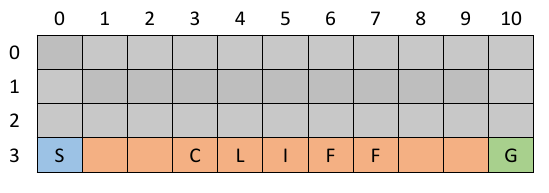

- S (blue) is the starting position
- G (green) is the goal
- Orange cells are cliff cells

At each timestep, the agent can be in only one cell. The agent has available the following actions:

1. Move Up
2. Move Down
3. Move Right
4. Move Left

If a move would make the agent go "out of bounds", then the move has no effect and the agent remains in place. The agent receives the following rewards:

- $-1$ for each step
- $-100$ for falling of the cliff
- $0$ for stepping on goal

The environment "stops" when the agent reaches the goal or steps falls off the cliff.

We first need to define the *Markov Decision Process* (MDP) for this problem/world.

In [198]:
# Let's first import modules
import numpy as np # Linear Algebra
import matplotlib.pyplot as plt # Plotting
import copy

In [199]:
### TO-DO: Define the state space. We want to define each cell with a tuple (i,j), 
### and we want to save all cells/states in a list called 'states' (x goes from 0 to 3 and y from 0 to 10).
### ANSWER:
states = [(i, j) for i in range(4) for j in range(11)]
### END of ANSWER

def is_cliff(s):
    return (s[0] == 3 and s[1] > 0 and s[1] < 10)

def is_terminal(s):
    return (s == (3, 10))

### TO-DO: Define the action space. This is a list of all possible actions. Save it in a variable named 'actions'.
### ANSWER:
actions = ["Move Up", "Move Down", "Move Left", "Move Right"]
### END of ANSWER

### Helper function: Compute the intended next state (before any cliff reset)
def intended_next_state(state, action):
    i, j = state
    if action == "Move Up":
        i -= 1
    elif action == "Move Down":
        i += 1
    elif action == "Move Left":
        j -= 1
    elif action == "Move Right":
        j += 1
    # Clamp to grid boundaries
    i = max(0, min(i, 3))
    j = max(0, min(j, 10))
    return (i, j)

### TO-DO: Define a world_step function (aka the system dynamics). 
### The function takes as input the current state (state) and the action to perform 
### and returns the new state (a tuple).
def world_step(state, action):
    ### ANSWER:
    next_state = intended_next_state(state, action)
    # If the intended state is a cliff, reset to the start state
    if is_cliff(next_state):
        return (3, 0)
    else:
        return next_state
    ### END of ANSWER

# Let's define the reward table/function
reward = {}
for s in states:
    for a in actions:
        ### TO-DO: Fill with values
        ### ANSWER:
        # Use the intended next state (without resetting) for reward calculation.
        next_s_intended = intended_next_state(s, a)
        if is_cliff(next_s_intended):
            reward[(s, a)] = -100.  # penalty for falling off the cliff
        elif is_terminal(next_s_intended):
            reward[(s, a)] = 0.     # terminal reward
        else:
            reward[(s, a)] = -1.    # default step cost
        ### END of ANSWER


In [200]:
assert(len(states) == 44)
assert(len(actions) == 4)


In [201]:
for a in actions:
    assert(reward[((1, 1), a)] == -1.)
    
assert(reward[((3, 1), 'Move Right')] == reward[((3, 2), 'Move Right')] == -100.)
assert(reward[((3, 10), 'Move Right')] == 0.)


### SARSA: On-Policy TD Learning

1. Initialize $Q(\boldsymbol{s},\boldsymbol{a})=0, \forall\boldsymbol{s}\in\mathcal{S}, \forall\boldsymbol{a}\in\mathcal{A}$
2. At every step:
   1. we observe the state $\boldsymbol{s}$
   2. we select and execute an action according to our policy $\boldsymbol{a}\sim\pi(\boldsymbol{s})$
   3. we end up at state $\boldsymbol{s}'$ and receive reward $r$
   4. we select $\boldsymbol{a}'$ using $Q$ and $\boldsymbol{s}'$ (e.g. using $\epsilon-\text{greedy}$)
   5. $Q(\boldsymbol{s},\boldsymbol{a}) = Q(\boldsymbol{s},\boldsymbol{a}) + \alpha\Big(r + \gamma Q(\boldsymbol{s}',\boldsymbol{a}') - Q(\boldsymbol{s},\boldsymbol{a})\Big)$

Let's implement it.

In [202]:
# First let's create the Q-function
N_states = len(states)
N_actions = len(actions)

# No need to keep an explicit policy representation, only the Q function is needed
Q = {}
### TO-DO: Initialize Q-function with zeros for all states. Q function is a dictionary that keys are tuples of the form (s,a)
### ANSWER: Insert code here
for s in states:
    for a in actions:
        Q[(s, a)] = 0.0
### END of ANSWER

# Policy given the Q-function
def pi(s, behavior="greedy", epsilon=0.1):
    ### TO-DO: Create ε-greedy policy. The function should return an action.
    ### ANSWER: Insert code here
    # 1. Find the Q-values for all actions in the current state
    q_values = np.array([Q[(s, a)] for a in actions])
    max_q = np.max(q_values)
    
    # 2. Identify which actions yield the maximum Q-value
    best_actions = [a for a, q_val in zip(actions, q_values) if q_val == max_q]
    
    # 3. Depending on the behavior, select an action
    if behavior == "greedy":
        # Choose randomly among the best actions if there's a tie
        return np.random.choice(best_actions)
    elif behavior == "epsilon-greedy":
        # With probability epsilon, choose any action at random
        # With probability (1 - epsilon), choose from the best actions
        if np.random.rand() < epsilon:
            return np.random.choice(actions)
        else:
            return np.random.choice(best_actions)
    elif behavior == "stochastic":
        # Compute softmax probabilities for all actions using a temperature of 1.0
        # Subtract the max Q-value for numerical stability
        exp_q = np.exp(q_values - np.max(q_values))
        probs = exp_q / np.sum(exp_q)
        return np.random.choice(actions, p=probs)
    else:
        raise ValueError(f"Unknown behavior: {behavior}")
    ### END of ANSWER

In [203]:
for s in states:
    assert(Q[s, 'Move Right'] == 0.)


In [204]:
# For testing
np.random.seed(1) # fix seed for testing
Q[(0, 0), 'Move Right'] = 10.

assert(pi((0, 0), "stochastic") == 'Move Right')


# Reset state
np.random.seed(None)
Q[(0, 0), 'Move Right'] = 0.

In [221]:
# Now we need to interact with the environment
N_episodes = 1000
gamma = 1. # episodic setting
alpha = 0.25
epsilon = 0.1
max_steps = 500

all_rewards = [] # for plotting
previous_reward = None
alpha_reward = 0.8

np.random.seed(5) # fix seed for testing

for i in range(N_episodes):
    ### TO-DO: Reset the world to the initial state. In other words, set the variable named 'state' with the value of the initial state (a tuple)
    ### ANSWER: Insert code here
    state = (3, 0)
    action = pi(state, behavior="epsilon-greedy", epsilon=0.1)
    ### END of ANSWER

    # let's run one episode and collect the data
    rewards = []

    for step in range(max_steps):
        ### TO-DO: Sample an action using the `pi` function. The action should be saved in a variable named 'action'
        ### ANSWER: Insert code here
        # (Do nothing here because 'action' is already set from the previous iteration)
        ### END of ANSWER

        # We now move the world one step with `world_step`
        next_state = world_step(state, action)

        ### TO-DO: Compute the reward. The reward should be saved in a variable named 'r'. 
        ### ANSWER: Insert code here
        r = reward[(state, action)]
        ### END of ANSWER

        # We check if the episode is finished or not
        done = is_cliff(next_state) or is_terminal(next_state)

        # Book-keeping
        rewards.append(r)

        ### TO-DO: Implement SARSA update
        ### ANSWER: Insert code here
        if done:
            Q[(state, action)] = Q[(state, action)] + alpha * (r - Q[(state, action)])
        else:
            next_action = pi(next_state, behavior="epsilon-greedy", epsilon=0.1)
            Q[(state, action)] = Q[(state, action)] + alpha * (
                r + gamma * Q[(next_state, next_action)] - Q[(state, action)]
            )
            action = next_action
        ### END of ANSWER

        if done:
            break
        state = copy.copy(next_state)

    if previous_reward is None:
        previous_reward = np.sum(rewards)
    else:
        previous_reward = alpha_reward * previous_reward + (1. - alpha_reward) * np.sum(rewards)
        #print("Episode #" + str(i) + ": " + str(previous_reward))
    all_rewards.append(previous_reward)


Episode #1: -15.0
Episode #2: -15.799999999999999
Episode #3: -15.44
Episode #4: -15.352
Episode #5: -15.6816
Episode #6: -15.14528
Episode #7: -14.716224
Episode #8: -15.1729792
Episode #9: -15.138383359999999
Episode #10: -14.710706688
Episode #11: -14.7685653504
Episode #12: -14.81485228032
Episode #13: -14.451881824256
Episode #14: -14.7615054594048
Episode #15: -14.80920436752384
Episode #16: -14.447363494019072
Episode #17: -15.357890795215257
Episode #18: -16.086312636172202
Episode #19: -15.469050108937763
Episode #20: -15.37524008715021
Episode #21: -15.300192069720168
Episode #22: -15.440153655776134
Episode #23: -15.752122924620906
Episode #24: -15.201698339696724
Episode #25: -15.36135867175738
Episode #26: -15.689086937405904
Episode #27: -16.75126954992472
Episode #28: -16.00101563993978
Episode #29: -15.800812511951825
Episode #30: -15.640650009561462
Episode #31: -16.51252000764917
Episode #32: -16.610016006119334
Episode #33: -16.688012804895468
Episode #34: -16.350410

In [222]:
assert(np.isclose(all_rewards[0], -65.))
assert(np.isclose(all_rewards[4], -97.25439999999999))
assert(np.isclose(all_rewards[-1], -16.677367188390097))


AssertionError: 

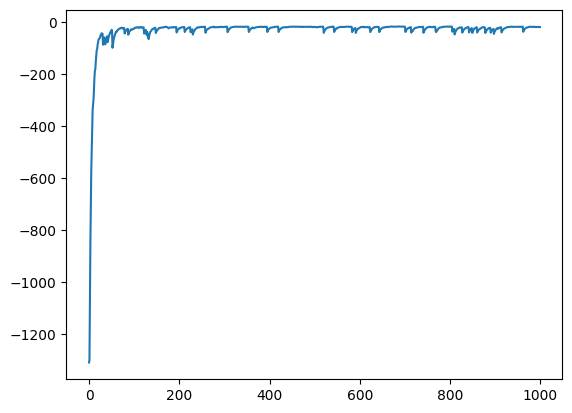

In [207]:
# Let's plot the learning process
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(range(len(all_rewards)), all_rewards, label='SARSA')

plt.show();

In [208]:
# Now let's do an episode with the greedy policy (aka the best learned)
np.random.seed(5) # fix seed for testing

### TO-DO: Reset the world to the initial state. In other words, set the variable named 'state' with the value of the initial state (a tuple)
### ANSWER: Insert code here
state = (3, 0)
### END of ANSWER

# let's run one episode and collect the data
rewards = []

for _ in range(max_steps):
    ### TO-DO: Sample an action using the `pi` function. The action should be saved in a variable named 'action'. Now use the greedy action!
    ### ANSWER: Insert code here
    action = pi(state, behavior="greedy")
    ### END of ANSWER

    # We now move the world one step with `world_step`
    next_state = world_step(state, action)

    ### TO-DO: Compute the reward. The reward should be saved in a variable named 'r'. 
    ### ANSWER: Insert code here
    r = reward[(state, action)]
    ### END of ANSWER

    # We check if the episode is finished or not
    done = is_cliff(next_state) or is_terminal(next_state)

    # Book-keeping
    rewards.append(r)

    if done:
        break
    state = copy.copy(next_state)

print('Episode reward is:', np.sum(rewards))


Episode reward is: -15.0


In [209]:
assert(np.isclose(np.sum(rewards), -15.))

### Q-Learning: Off-Policy TD Learning

1. Initialize $Q(\boldsymbol{s},\boldsymbol{a})=0, \forall\boldsymbol{s}\in\mathcal{S}, \forall\boldsymbol{a}\in\mathcal{A}$
2. At every step:
   1. we observe the state $\boldsymbol{s}$
   2. we select and execute an action according to our policy $\boldsymbol{a}\sim\pi(\boldsymbol{s})$
   3. we end up at state $\boldsymbol{s}'$ and receive reward $r$
   4. $Q(\boldsymbol{s},\boldsymbol{a}) = Q(\boldsymbol{s},\boldsymbol{a}) + \alpha\Big(r + \gamma\max_zQ(\boldsymbol{s}',\boldsymbol{z}) - Q(\boldsymbol{s},\boldsymbol{a})\Big)$

Let's implement it.

In [210]:
# First let's create the Q-function -- just copy paste from SARSA
N_states = len(states)
N_actions = len(actions)

# No need to keep an explicit policy representation, only the Q function is needed
Q = {}
### TO-DO: Initialize Q-function with zeros for all states. Q function is a dictionary that keys are tuples of the form (s,a). Copy paste from above.
### ANSWER: Insert code here
for s in states:
    for a in actions:
        Q[(s, a)] = 0.0
### END of ANSWER

In [211]:
# Now we need to interact with the environment
N_episodes = 1000
gamma = 1. # episodic setting
alpha = 0.25
epsilon = 0.1
max_steps = 500

all_rewards_q = [] # for plotting
previous_reward = None
alpha_reward = 0.8

np.random.seed(5) # fix seed for testing

for i in range(N_episodes):
    ### TO-DO: Reset the world to the initial state. In other words, set the variable named 'state' with the value of the initial state (a tuple)
    ### ANSWER: Insert code here
    state = (3, 0)
    # Use ε-greedy for the initial action
    action = pi(state, behavior="epsilon-greedy", epsilon=0.1)
    ### END of ANSWER

    # let's run one episode and collect the data
    rewards = []

    for _ in range(max_steps):
        # We now move the world one step with `world_step`
        next_state = world_step(state, action)

        ### TO-DO: Compute the reward. The reward should be saved in a variable named 'r'.
        ### ANSWER: Insert code here
        r = reward[(state, action)]
        ### END of ANSWER

        # We check if the episode is finished or not
        done = is_cliff(next_state) or is_terminal(next_state)

        # Book-keeping
        rewards.append(r)
        # print(state, action, next_state, r, done)

        ### TO-DO: Implement Q-learning update
        ### ANSWER: Insert code here
        if done:
            # Terminal update
            Q[(state, action)] += alpha * (r - Q[(state, action)])
        else:
            # Q-learning uses max_a' Q(s',a')
            next_q_values = [Q[(next_state, a2)] for a2 in actions]
            max_next_q = max(next_q_values)
            Q[(state, action)] += alpha * (
                r + gamma * max_next_q - Q[(state, action)]
            )
        ### END of ANSWER

        if done:
            break

        # Move to the next state
        state = copy.copy(next_state)
        ### TO-DO: Sample an action using the `pi` function. The action should be saved in a variable named 'action'
        # now that we've updated Q, pick a new action from next_state
        ### ANSWER: Insert code here
        action = pi(state, behavior="epsilon-greedy", epsilon=0.1)
        ### END of ANSWER

    # Smoothing the episode return for plotting
    episode_return = np.sum(rewards)
    if previous_reward is None:
        previous_reward = episode_return
    else:
        previous_reward = alpha_reward * previous_reward + (1. - alpha_reward) * episode_return
    all_rewards_q.append(previous_reward)

In [212]:
assert(np.isclose(all_rewards_q[0], -108.))
assert(np.isclose(all_rewards_q[4], -124.536))
assert(np.isclose(all_rewards_q[-1], -29.1192530203508))


AssertionError: 

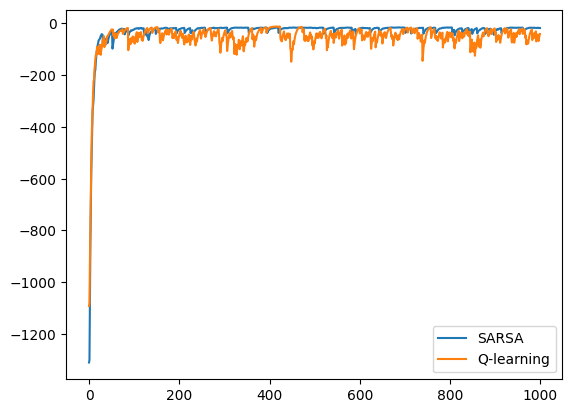

In [213]:
# Let's plot the learning process
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(range(len(all_rewards)), all_rewards, label='SARSA')
ax.plot(range(len(all_rewards)), all_rewards_q, label='Q-learning')

ax.legend()

plt.show();

In [214]:
# Now let's do an episode with the greedy policy (aka the best learned)
np.random.seed(5) # fix seed for testing

### TO-DO: Reset the world to the initial state. In other words, set the variable named 'state' with the value of the initial state (a tuple)
### ANSWER: Insert code here
### END of ANSWER

# let's run one episode and collect the data
rewards = []

for _ in range(max_steps):
    ### TO-DO: Sample an action using the `pi` function. The action should be saved in a variable named 'action'. Now use the greedy action!
    ### ANSWER: Insert code here
    ### END of ANSWER
    # We now move the world one step with `world_step`
    next_state = world_step(state, action)

    ### TO-DO: Compute the reward. The reward should be saved in a variable named 'r'. 
    ### ANSWER: Insert code here
    ### END of ANSWER

    # We check if the episode is finished or not
    done = is_cliff(next_state) or is_terminal(next_state)

    # Book-keeping
    rewards.append(r)

    if done:
        break
    state = copy.copy(next_state)
print('Episode reward is:', np.sum(rewards))

Episode reward is: 0.0


In [215]:
assert(np.isclose(np.sum(rewards), -11.))

AssertionError: 

### Expected SARSA: Off-Policy TD Learning

1. Initialize $Q(\boldsymbol{s},\boldsymbol{a})=0, \forall\boldsymbol{s}\in\mathcal{S}, \forall\boldsymbol{a}\in\mathcal{A}$
2. At every step:
   1. we observe the state $\boldsymbol{s}$
   2. we select and execute an action according to our policy $\boldsymbol{a}\sim\pi(\boldsymbol{s})$
   3. we end up at state $\boldsymbol{s}'$ and receive reward $r$
   4. $Q(\boldsymbol{s},\boldsymbol{a}) = Q(\boldsymbol{s},\boldsymbol{a}) + \alpha\Big(r + \gamma\sum_{a'}[\pi(\boldsymbol{a}'|\boldsymbol{s}')Q(\boldsymbol{s}',\boldsymbol{a}')] - Q(\boldsymbol{s},\boldsymbol{a})\Big)$

Let's implement it.

In [216]:
# First let's create the Q-function -- just copy paste from previous
N_states = len(states)
N_actions = len(actions)

# No need to keep an explicit policy representation, only the Q function is needed
Q = {}
### TO-DO: Initialize Q-function with zeros for all states. Q function is a dictionary that keys are tuples of the form (s,a). Copy paste from above.
### ANSWER: Insert code here
for s in states:
    for a in actions:
        Q[(s, a)] = 0.0
### END of ANSWER


In [217]:
# Now we need to interact with the environment
N_episodes = 1000
gamma = 1. # episodic setting
alpha = 0.25
epsilon = 0.1
max_steps = 500

all_rewards_es = [] # for plotting
previous_reward = None
alpha_reward = 0.8

np.random.seed(5) # fix seed for testing

for i in range(N_episodes):
    ### TO-DO: Reset the world to the initial state. In other words, set the variable named 'state' with the value of the initial state (a tuple)
    ### ANSWER: Insert code here
    state = (3, 0)
    ### END of ANSWER

    # let's run one episode and collect the data
    rewards = []

    for _ in range(max_steps):
        # we use the stochastic policy during learning
        ### TO-DO: Sample an action using the `pi` function. The action should be saved in a variable named 'action'
        ### ANSWER: Insert code here
        action = pi(state, behavior="epsilon-greedy", epsilon=0.1)
        ### END of ANSWER

        # We now move the world one step with `world_step`
        next_state = world_step(state, action)

        ### TO-DO: Compute the reward. The reward should be saved in a variable named 'r'.
        ### ANSWER: Insert code here
        r = reward[(state, action)]
        ### END of ANSWER

        # We check if the episode is finished or not
        done = is_cliff(next_state) or is_terminal(next_state)

        # Book-keeping
        rewards.append(r)
        # print(state, actions[action], next_state, r, done)

        ### TO-DO: Implement Expected-SARSA update
        ### ANSWER: Insert code here
        if done:
            # If next_state is terminal or cliff, there's no future Q-value
            Q[(state, action)] += alpha * (r - Q[(state, action)])
        else:
            # 1. Retrieve Q-values for all actions in next_state
            next_q_values = [Q[(next_state, a2)] for a2 in actions]
            max_q = max(next_q_values)
            
            # 2. Identify best actions
            best_actions = [a2 for a2, q_val in zip(actions, next_q_values) if q_val == max_q]
            
            # 3. Compute expected Q-value under ε-greedy policy
            E = 0.0
            for a2, q_val in zip(actions, next_q_values):
                if a2 in best_actions:
                    # Probability = (1 - ε)/(# of best_actions) + ε/(|actions|)
                    p = (1.0 - epsilon) / len(best_actions) + (epsilon / len(actions))
                else:
                    # Probability = ε/(|actions|)
                    p = epsilon / len(actions)
                E += p * q_val
            
            # 4. Update Q(s,a) with the expected return
            Q[(state, action)] += alpha * (r + gamma * E - Q[(state, action)])
        ### END of ANSWER

        if done:
            break

        state = copy.copy(next_state)

    if previous_reward is None:
        previous_reward = np.sum(rewards)
    else:
        previous_reward = alpha_reward * previous_reward + (1. - alpha_reward) * np.sum(rewards)
    # print("Episode #" + str(i) + ": " + str(previous_reward))
    all_rewards_es.append(previous_reward)


In [218]:
assert(np.isclose(all_rewards_es[0], -108.))
assert(np.isclose(all_rewards_es[4], -107.456))
assert(np.isclose(all_rewards_es[-1], -30.25284672079732))


AssertionError: 

In [ ]:
# Let's plot the learning process
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(range(len(all_rewards)), all_rewards, label='SARSA')
ax.plot(range(len(all_rewards)), all_rewards_q, label='Q-learning')
ax.plot(range(len(all_rewards)), all_rewards_es, label='Expected SARSA')

ax.legend()

plt.show();

In [219]:
# Now let's do an episode with the greedy policy (aka the best learned)
np.random.seed(5) # fix seed for testing

### TO-DO: Reset the world to the initial state. In other words, set the variable named 'state' with the value of the initial state (a tuple)
### ANSWER: Insert code here
state = (3, 0)
### END of ANSWER

# let's run one episode and collect the data
rewards = []

for _ in range(max_steps):
    ### TO-DO: Sample an action using the pi function. The action should be saved in a variable named 'action'. Now use the greedy action!
    ### ANSWER: Insert code here
    action = pi(state, behavior="greedy")
    ### END of ANSWER

    # We now move the world one step with world_step
    next_state = world_step(state, action)

    ### TO-DO: Compute the reward. The reward should be saved in a variable named 'r'. 
    ### ANSWER: Insert code here
    r = reward[(state, action)]
    ### END of ANSWER

    # We check if the episode is finished or not
    done = is_cliff(next_state) or is_terminal(next_state)

    # Book-keeping
    rewards.append(r)

    if done:
        break
    state = copy.copy(next_state)

print('Episode reward is:', np.sum(rewards))

Episode reward is: -13.0


In [220]:
assert(np.isclose(np.sum(rewards), -11.))

AssertionError: 